# Introduction to Partial Derivatives

A guided notebook on **partial derivatives**.

This notebook explains:

- functions of several variables
- what a partial derivative means
- how to treat one variable as constant
- the example $f(x,y)=x^2+y^2$
- geometric intuition using surface slices
- symbolic checks with SymPy
- numerical approximations
- a preview of the gradient

This notebook follows the uploaded guidelines template.


## 1. Introduction

In single-variable calculus, we study functions like:

$$
y=f(x)
$$

There is one input and one output.

But many real-world quantities depend on more than one input.

Examples:

$$
z=f(x,y)
$$

could represent:

- height of a surface at position $(x,y)$
- temperature depending on longitude and latitude
- profit depending on price and demand
- portfolio return depending on multiple market factors

For functions of several variables, we ask:

> How does the output change when one input changes while the other inputs are held fixed?

This is the idea of a **partial derivative**.


## 2. Visual Intuition

The image below shows the key idea.

For

$$
f(x,y)=x^2+y^2
$$

we can find two partial derivatives:

$$
\frac{\partial f}{\partial x}=2x
$$

and

$$
\frac{\partial f}{\partial y}=2y
$$

When finding one partial derivative, we treat the other variable as a constant.

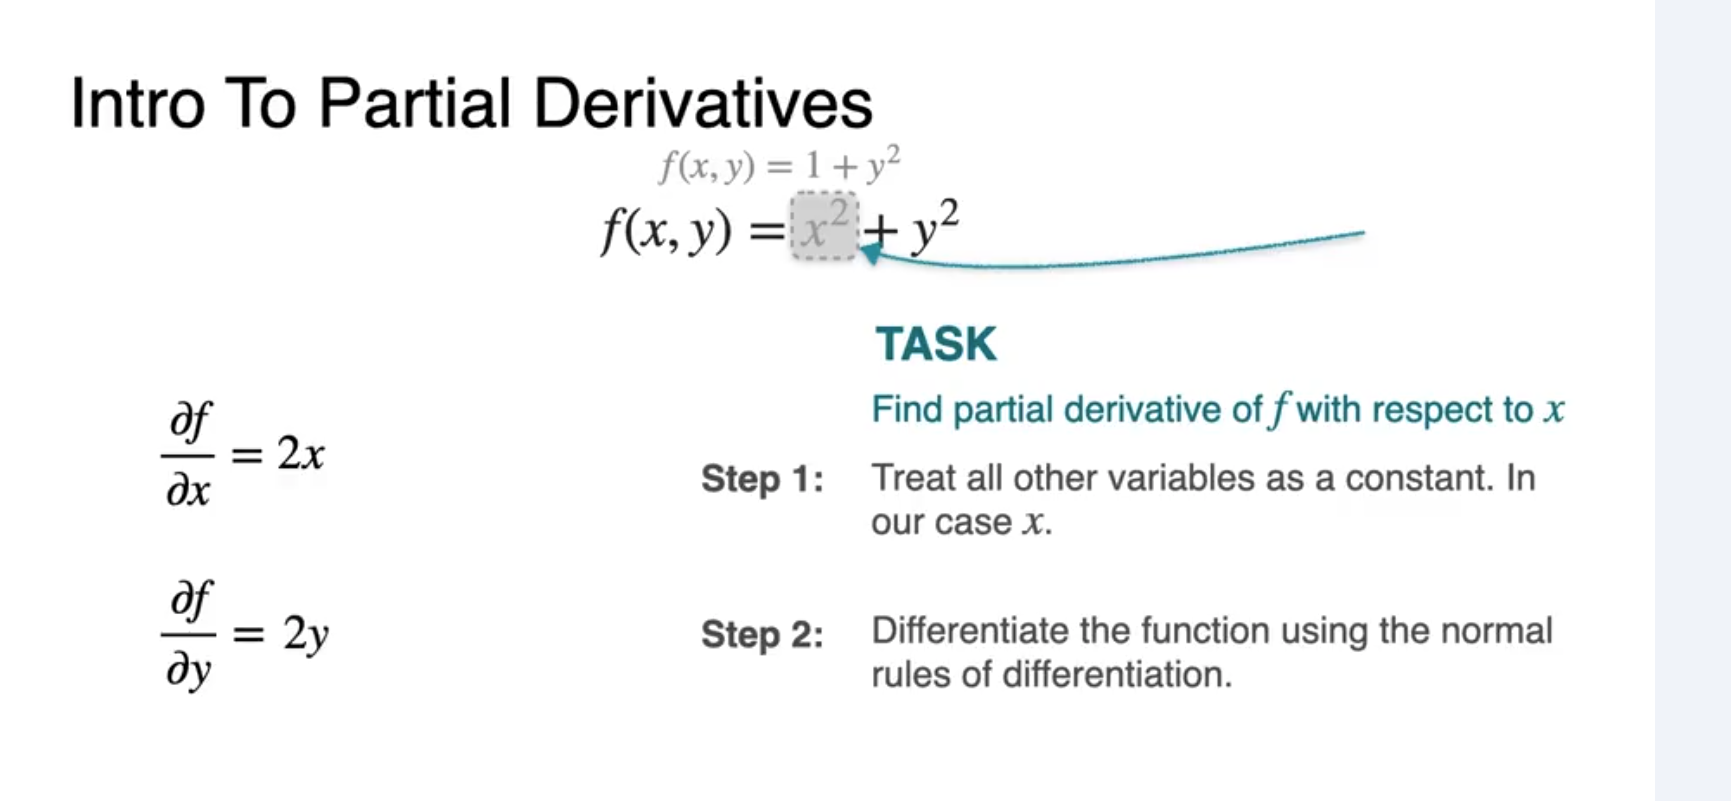


## 3. Functions of Two Variables

A function of two variables has the form:

$$
z=f(x,y)
$$

Here:

- $x$ and $y$ are input variables
- $z$ is the output
- the graph is usually a surface in 3D

Example:

$$
f(x,y)=x^2+y^2
$$

For each point $(x,y)$, the function returns a height:

$$
z=x^2+y^2
$$

This surface is a paraboloid.


## 4. What Is a Partial Derivative?

A partial derivative measures the rate of change of a multivariable function with respect to **one variable at a time**.

### Partial derivative with respect to $x$

$$
\frac{\partial f}{\partial x}
=
\lim_{h\to0}
\frac{f(x+h,y)-f(x,y)}{h}
$$

Here, $y$ is held constant.

### Partial derivative with respect to $y$

$$
\frac{\partial f}{\partial y}
=
\lim_{h\to0}
\frac{f(x,y+h)-f(x,y)}{h}
$$

Here, $x$ is held constant.


## 5. Notation

The partial derivative with respect to $x$ can be written as:

$$
\frac{\partial f}{\partial x}
$$

or

$$
f_x
$$

The partial derivative with respect to $y$ can be written as:

$$
\frac{\partial f}{\partial y}
$$

or

$$
f_y
$$

The symbol $\partial$ reminds us that we are differentiating a function of several variables with respect to only one variable.


## 6. Worked Example: $f(x,y)=x^2+y^2$

Let:

$$
f(x,y)=x^2+y^2
$$

### Find $f_x$

To find the partial derivative with respect to $x$, treat $y$ as constant.

$$
\frac{\partial}{\partial x}(x^2+y^2)
=
\frac{\partial}{\partial x}(x^2)
+
\frac{\partial}{\partial x}(y^2)
$$

Since $y^2$ is constant with respect to $x$:

$$
\frac{\partial}{\partial x}(y^2)=0
$$

So:

$$
f_x(x,y)=2x
$$

### Find $f_y$

To find the partial derivative with respect to $y$, treat $x$ as constant.

$$
\frac{\partial}{\partial y}(x^2+y^2)
=
\frac{\partial}{\partial y}(x^2)
+
\frac{\partial}{\partial y}(y^2)
$$

Since $x^2$ is constant with respect to $y$:

$$
\frac{\partial}{\partial y}(x^2)=0
$$

So:

$$
f_y(x,y)=2y
$$


## 7. Freezing One Variable

Partial derivatives can be understood by **freezing** one variable.

For:

$$
f(x,y)=x^2+y^2
$$

### Freeze $y=1$

Then:

$$
f(x,1)=x^2+1
$$

This is now a one-variable function of $x$.

Its derivative is:

$$
\frac{d}{dx}f(x,1)=2x
$$

### Freeze $x=2$

Then:

$$
f(2,y)=4+y^2
$$

This is now a one-variable function of $y$.

Its derivative is:

$$
\frac{d}{dy}f(2,y)=2y
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 8. Symbolic Check with SymPy

In [2]:
x, y = sp.symbols('x y')

f = x**2 + y**2

fx = sp.diff(f, x)
fy = sp.diff(f, y)

print("f(x,y) =", f)
print("f_x =", fx)
print("f_y =", fy)


f(x,y) = x**2 + y**2
f_x = 2*x
f_y = 2*y


## 9. 3D Visualization of the Surface

We plot:

$$
f(x,y)=x^2+y^2
$$

This surface is a paraboloid.


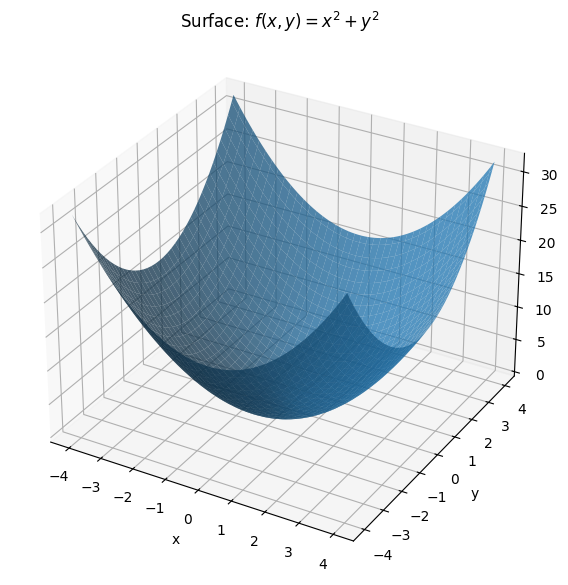

In [3]:
from mpl_toolkits.mplot3d import Axes3D

x_vals = np.linspace(-4, 4, 80)
y_vals = np.linspace(-4, 4, 80)

X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, alpha=0.75)

ax.set_title(r"Surface: $f(x,y)=x^2+y^2$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()


## 10. Surface Slices

A partial derivative is the slope of a slice of the surface.

### Slice in the $x$-direction

Fix $y=1$:

$$
f(x,1)=x^2+1
$$

### Slice in the $y$-direction

Fix $x=2$:

$$
f(2,y)=4+y^2
$$

Each slice is an ordinary one-variable function.


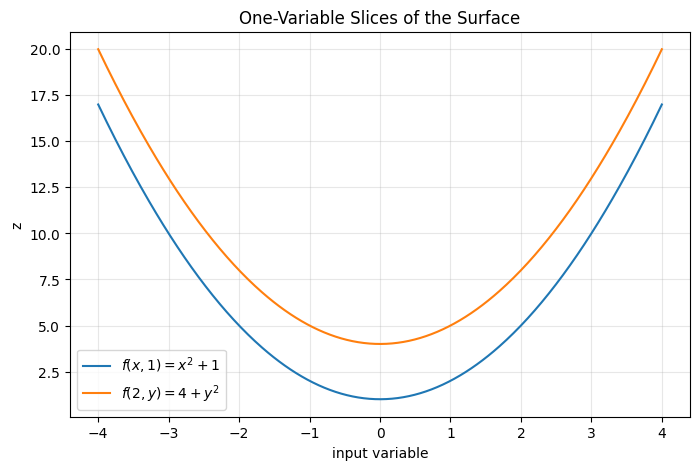

In [4]:
x_line = np.linspace(-4, 4, 400)
y_fixed = 1
z_x_slice = x_line**2 + y_fixed**2

y_line = np.linspace(-4, 4, 400)
x_fixed = 2
z_y_slice = x_fixed**2 + y_line**2

plt.figure(figsize=(8,5))
plt.plot(x_line, z_x_slice, label=r"$f(x,1)=x^2+1$")
plt.plot(y_line, z_y_slice, label=r"$f(2,y)=4+y^2$")
plt.title("One-Variable Slices of the Surface")
plt.xlabel("input variable")
plt.ylabel("z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 11. Slope at a Point

Let us evaluate the slopes at the point:

$$
(x,y)=(2,1)
$$

For

$$
f(x,y)=x^2+y^2
$$

we have:

$$
f_x(x,y)=2x
$$

and

$$
f_y(x,y)=2y
$$

Therefore:

$$
f_x(2,1)=4
$$

and

$$
f_y(2,1)=2
$$

Interpretation:

- moving in the $x$-direction near $(2,1)$, the surface has slope $4$
- moving in the $y$-direction near $(2,1)$, the surface has slope $2$


In [5]:
point_x = 2
point_y = 1

fx_value = 2 * point_x
fy_value = 2 * point_y
z_value = point_x**2 + point_y**2

print("Point:", (point_x, point_y, z_value))
print("f_x(2,1) =", fx_value)
print("f_y(2,1) =", fy_value)


Point: (2, 1, 5)
f_x(2,1) = 4
f_y(2,1) = 2


## 12. Numerical Approximation of Partial Derivatives

We can approximate partial derivatives using small differences.

For $f_x$:

$$
f_x(x,y)\approx\frac{f(x+h,y)-f(x,y)}{h}
$$

For $f_y$:

$$
f_y(x,y)\approx\frac{f(x,y+h)-f(x,y)}{h}
$$


In [6]:
def f_numeric(x, y):
    return x**2 + y**2

def partial_x(func, x, y, h=1e-6):
    return (func(x + h, y) - func(x, y)) / h

def partial_y(func, x, y, h=1e-6):
    return (func(x, y + h) - func(x, y)) / h

x0, y0 = 2, 1

print("Numerical f_x:", partial_x(f_numeric, x0, y0))
print("Exact f_x    :", 2*x0)
print()
print("Numerical f_y:", partial_y(f_numeric, x0, y0))
print("Exact f_y    :", 2*y0)


Numerical f_x: 4.0000010006480125
Exact f_x    : 4

Numerical f_y: 2.0000010003684565
Exact f_y    : 2


## 13. Worked Example 2

Find the partial derivatives of:

$$
f(x,y)=x^2y+\sin y
$$

### With respect to $x$

Treat $y$ as constant:

$$
f_x(x,y)=2xy
$$

because $\sin y$ is constant with respect to $x$.

### With respect to $y$

Treat $x$ as constant:

$$
f_y(x,y)=x^2+\cos y
$$

because the derivative of $x^2y$ with respect to $y$ is $x^2$.


In [7]:
f2 = x**2*y + sp.sin(y)

fx2 = sp.diff(f2, x)
fy2 = sp.diff(f2, y)

print("f(x,y) =", f2)
print("f_x =", fx2)
print("f_y =", fy2)


f(x,y) = x**2*y + sin(y)
f_x = 2*x*y
f_y = x**2 + cos(y)


## 14. Worked Example 3

Find the partial derivatives of:

$$
f(x,y)=e^{xy}
$$

### With respect to $x$

Treat $y$ as constant.

Use the chain rule:

$$
f_x(x,y)=e^{xy}\cdot y
$$

So:

$$
f_x(x,y)=y e^{xy}
$$

### With respect to $y$

Treat $x$ as constant.

Use the chain rule:

$$
f_y(x,y)=e^{xy}\cdot x
$$

So:

$$
f_y(x,y)=x e^{xy}
$$


In [8]:
f3 = sp.exp(x*y)

print("f(x,y) =", f3)
print("f_x =", sp.diff(f3, x))
print("f_y =", sp.diff(f3, y))


f(x,y) = exp(x*y)
f_x = y*exp(x*y)
f_y = x*exp(x*y)


## 15. Preview: The Gradient

The two partial derivatives can be collected into a vector called the **gradient**:

$$
\nabla f(x,y)
=
\begin{bmatrix}
f_x(x,y) \\
f_y(x,y)
\end{bmatrix}
$$

For:

$$
f(x,y)=x^2+y^2
$$

we get:

$$
\nabla f(x,y)
=
\begin{bmatrix}
2x \\
2y
\end{bmatrix}
$$

At $(2,1)$:

$$
\nabla f(2,1)
=
\begin{bmatrix}
4 \\
2
\end{bmatrix}
$$

The gradient points in the direction of steepest increase.


## 16. Common Mistakes

### Mistake 1: Differentiating both variables at once

When finding $f_x$, do **not** differentiate $y$.

When finding $f_y$, do **not** differentiate $x$.

### Mistake 2: Forgetting that constants disappear

For example:

$$
\frac{\partial}{\partial x}(y^2)=0
$$

because $y^2$ is constant with respect to $x$.

### Mistake 3: Confusing partial derivatives with total derivatives

Partial derivatives isolate one input direction at a time.


## 17. Exercises

### Basic

1. Find $f_x$ and $f_y$ for:

$$
f(x,y)=3x^2+4y^2
$$

2. Find $f_x$ and $f_y$ for:

$$
f(x,y)=xy
$$

### Intermediate

3. Find $f_x$ and $f_y$ for:

$$
f(x,y)=x^3y^2
$$

4. Find $f_x$ and $f_y$ for:

$$
f(x,y)=\ln(x+y)
$$

### Advanced

5. Find $f_x$ and $f_y$ for:

$$
f(x,y)=\sin(xy)
$$

6. Explain in words what $f_x(a,b)$ means geometrically.


## 18. Solutions / Checks

### 1.

$$
f_x=6x
$$

$$
f_y=8y
$$

### 2.

$$
f_x=y
$$

$$
f_y=x
$$

### 3.

$$
f_x=3x^2y^2
$$

$$
f_y=2x^3y
$$

### 4.

$$
f_x=\frac{1}{x+y}
$$

$$
f_y=\frac{1}{x+y}
$$

### 5.

$$
f_x=y\cos(xy)
$$

$$
f_y=x\cos(xy)
$$

### 6.

$f_x(a,b)$ is the slope of the surface in the $x$-direction at the point $(a,b)$. It is found by slicing the surface with $y=b$ and taking the ordinary derivative of that one-variable slice.


## 19. Conclusion

A partial derivative measures how a multivariable function changes when **one input changes** and the others are held constant.

For:

$$
f(x,y)=x^2+y^2
$$

we found:

$$
f_x=2x
$$

and

$$
f_y=2y
$$

Key idea:

- to compute $f_x$, treat $y$ as constant
- to compute $f_y$, treat $x$ as constant
- geometrically, partial derivatives are slopes of surface slices
- together, partial derivatives form the gradient

Partial derivatives are the foundation for tangent planes, optimization, gradients, and multivariable calculus.
